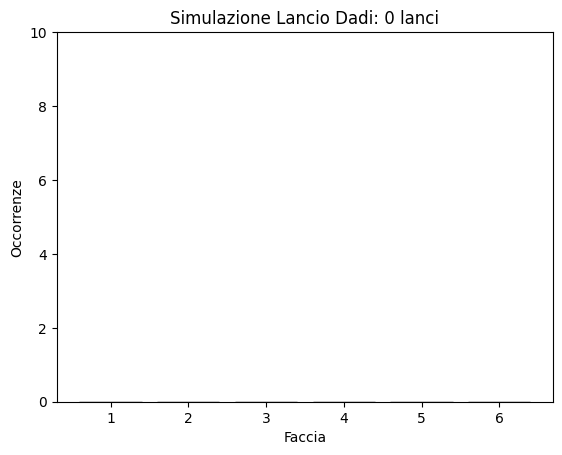

In [1]:
import random as rm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

class Dado:
    def __init__(self, nFaccie):
        self.nFaccie = nFaccie
        
    def lancio(self):
        return rm.randint(1, self.nFaccie)

# --- Configurazione Iniziale ---

d1 = Dado(6)
results = {faccia: 0 for faccia in range(1, d1.nFaccie + 1)}

# Prepariamo il "foglio" per il grafico
fig, ax = plt.subplots()
x = list(results.keys())
y = list(results.values())

# Disegniamo le barre iniziali (tutte a zero) e salviamo il riferimento 'barre'
# Ci serve salvarlo per poter modificare l'altezza delle barre dopo
barre = ax.bar(x, y, color='skyblue', edgecolor='black')

# Impostazioni estetiche fisse
ax.set_title("Simulazione Lancio Dadi: 0 lanci")
ax.set_xlabel("Faccia")
ax.set_ylabel("Occorrenze")
ax.set_ylim(0, 10)  # Limite iniziale asse Y (si adatterà dinamicamente)

# --- La Funzione di Aggiornamento ---
# Questa funzione viene chiamata automaticamente ad ogni "frame" dell'animazione
def update(frame):
    # 1. Lancia il dado una volta
    uscita = d1.lancio()
    
    # 2. Aggiorna i dati nel dizionario
    results[uscita] += 1
    
    # 3. Aggiorna GRAFICAMENTE l'altezza delle barre
    # Non ridisegniamo tutto il grafico (sarebbe lento), modifichiamo solo le altezze
    max_occorrenze = 0
    for rect, faccia in zip(barre, x):
        altezza = results[faccia]
        rect.set_height(altezza) # Modifica l'altezza della barra specifica
        if altezza > max_occorrenze:
            max_occorrenze = altezza

    # 4. Aggiorna il titolo con il numero totale di lanci (frame + 1)
    ax.set_title(f"Simulazione Lancio Dadi: {frame + 1} lanci")

    # 5. Adatta l'asse Y se le barre diventano troppo alte
    current_ymax = ax.get_ylim()[1]
    if max_occorrenze >= current_ymax:
        ax.set_ylim(0, current_ymax + 10) # Alza il tetto dell'asse Y di 10
        plt.draw() # Forza il ridisegno degli assi

# --- Avvio Animazione ---

# fig: la figura su cui disegnare
# update: la funzione da chiamare ripetutamente
# interval: millisecondi tra un frame e l'altro (velocità)
# cache_frame_data=False: evita di salvare la cache se l'animazione è infinita
ani = FuncAnimation(fig, update, interval=100, cache_frame_data=False)

plt.show()